# Preambolo

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import math
import sys
from scipy.constants import g
from uncertainties import ufloat
import uncertainties.umath as unm
from uncertainties import unumpy as unp
from uncertainties.umath import sqrt
from uncertainties import ufloat
import sys
import os
percorso_main = os.path.abspath('..')
if percorso_main not in sys.path:
    sys.path.append(percorso_main)
from Libreria_python import analisi_dati as ad
from scipy.optimize import curve_fit

# Tubo Aperto

In [84]:
df=pd.read_excel('Tubo risonanza.xlsx', sheet_name=0)
df=df.fillna('')
df

,n,Frequenza (hz),Incertezza (hz),D diametro del tubo aperto,Temperatura stanza (k)
0,1.0,190.0,5.0,0.035,296.15
1,2.0,381.0,5.0,Incertezza (m),Incertezza temperatura (k)
2,3.0,561.0,5.0,0.005,0.5
3,4.0,760.0,5.0,Lunghezza tubo (m),Massa molare aria (kg/mol)
4,5.0,936.0,5.0,0.9,0.028965
5,,,,Incertezza (m),Incertezza (kg/mol)
6,,,,0.01,0.0005
7,,,,,γ
8,,,,,1.4
9,,,,,R gas ideale


Il risultato del fit y = k·x è:
  k = 188.27273±0.67420


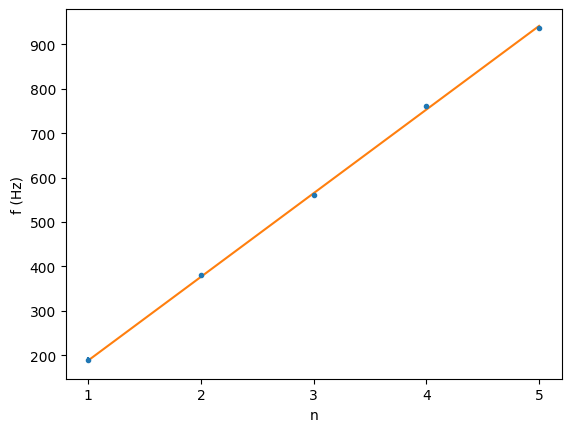

Il risultato del test del χ² è:
  χ²               = 4.5563636
  Gradi di libertà = 4
  χ² ridotto       = 1.1390909
  Il p-value associato è: 0.33591643
Velocità del suono sperimentale= 349.43±4.24
Velocità del suono teorica: 344.99±2.99
Test di compatibilità tra v_exp e v_teo: |t| = 0.8564692


In [100]:
n=df.iloc[0:5, 0]
n=pd.to_numeric(n, errors='coerce').dropna().values
f=df.iloc[0:5, 1]
f=pd.to_numeric(f, errors='coerce').dropna().values
sf = df.iloc[0:5, 2]
sf = pd.to_numeric(sf, errors='coerce').dropna().values
k = ad.minquadw_kx(n, f, sf)
def retta(x, k):
    return k * x
t= np.linspace(min(n), max(n))
plt.errorbar(n, f, yerr=sf, fmt='o', ls='none', label='Dati', ms=3)
plt.xticks(n)
plt.plot(t, retta(t, k.nominal_value))
plt.xlabel(r'n')
plt.ylabel(r'f (Hz)')
plt.show()

print("="*70)

ad.chi_quadro(f, k*n, sf, 1)
print("="*70)

L=ufloat(df.iloc[4, 3], df.iloc[6, 3])
D=ufloat(df.iloc[0, 3], df.iloc[2, 3])
v=2*(L+(0.8*D))*k
print(f"Velocità del suono sperimentale= {v:.5P}")

R=df.iloc[10, 4]
γ=df.iloc[8, 4]
M=ufloat(df.iloc[4, 4], df.iloc[6, 4])
T=ufloat(df.iloc[0, 4], df.iloc[2, 4])
v_suono=sqrt((γ*R*T)/M)
print(f"Velocità del suono teorica: {v_suono:.5P}")
print("="*70)

ad.t_test(v, v_suono, "v_exp", "v_teo")
print("="*70)

# Ventri e nodi

In [86]:
df2=pd.read_excel('Tubo risonanza.xlsx', sheet_name=1)
df2=df2.fillna('')
df2

,n=4,n,Distanza (m),Incertezza (m),λ_n teorica,λ_n/2 osservata,V suono (m/s)
0,Ventri,1.5,0.345,0.005,0.45393,0.228,344.98679
1,,2.5,0.560,0.005,,0.225,Frequenza (hz)
2,,3.5,0.788,0.005,,0.220,760
3,Nodi,1.0,0.230,0.005,,0.215,
4,,2.0,0.450,0.005,Media,0.222,
5,,3.0,0.675,0.005,λ_n sperimentale,0.444,


In [87]:
d_val = pd.to_numeric(df2.iloc[0:6, 2], errors='coerce').dropna().values
d_err = pd.to_numeric(df2.iloc[0:6, 3], errors='coerce').dropna().values
d_sperimentali = unp.uarray(d_val, d_err)
n_1 = pd.to_numeric(df2.iloc[0:6, 1], errors='coerce').dropna().values
f_fissa = df2.iloc[2, 6]

d_teoriche = n_1 * v_suono / (2 * f_fissa)

print("="*70)
for i in range(len(d_teoriche)):
    print(f"Distanza teorica {i+1}: {d_teoriche[i]:.4P}")
    print(f"Distanza sperimentale {i+1}: {d_sperimentali[i]:.4P}")
    ad.t_test(d_teoriche[i], d_sperimentali[i], "d_teo", "d_exp" )
    print("="*70)


Distanza teorica 1: 0.3404±0.0030
Distanza sperimentale 1: 0.3450±0.0050
Test di compatibilità tra d_teo e d_exp: |t| = 0.78401701
Distanza teorica 2: 0.5674±0.0049
Distanza sperimentale 2: 0.5600±0.0050
Test di compatibilità tra d_teo e d_exp: |t| = 1.056616
Distanza teorica 3: 0.7944±0.0069
Distanza sperimentale 3: 0.7880±0.0050
Test di compatibilità tra d_teo e d_exp: |t| = 0.74920102
Distanza teorica 4: 0.2270±0.0020
Distanza sperimentale 4: 0.2300±0.0050
Test di compatibilità tra d_teo e d_exp: |t| = 0.5648123
Distanza teorica 5: 0.4539±0.0039
Distanza sperimentale 5: 0.4500±0.0050
Test di compatibilità tra d_teo e d_exp: |t| = 0.61755824
Distanza teorica 6: 0.6809±0.0059
Distanza sperimentale 6: 0.6750±0.0050
Test di compatibilità tra d_teo e d_exp: |t| = 0.76187139


# Tubo Chiuso ad una estremità

In [88]:
df9=pd.read_excel('Tubo risonanza.xlsx', sheet_name=2)
df9.fillna('')


,Unnamed: 0,80 cm,Unnamed: 2,65 cm,Unnamed: 4,55 cm,Unnamed: 6,Temperatura stanza (k),Distanza dal tubo
0,n,Frequenza (hz),Incertezza (hz),Frequenza (hz),Incertezza (hz),Frequenza (hz),Incertezza (hz),294.65,"1,5 cm"
1,1,105,5,129,5,151,5,Incertezza temperatura (k),
2,3,316,5,387,5,457,5,0.5,
3,5,526,5,646,5,760,5,,
4,7,737,5,904,5,1063,5,,
5,9,949,5,1163,5,1380,5,,
6,11,1155,5,1430,5,1680,5,,


Il risultato del fit y = k·x è:
  k = 105.20280±0.29566
Il risultato del fit y = k·x è:
  k = 129.52797±0.29566
Il risultato del fit y = k·x è:
  k = 152.66783±0.29566


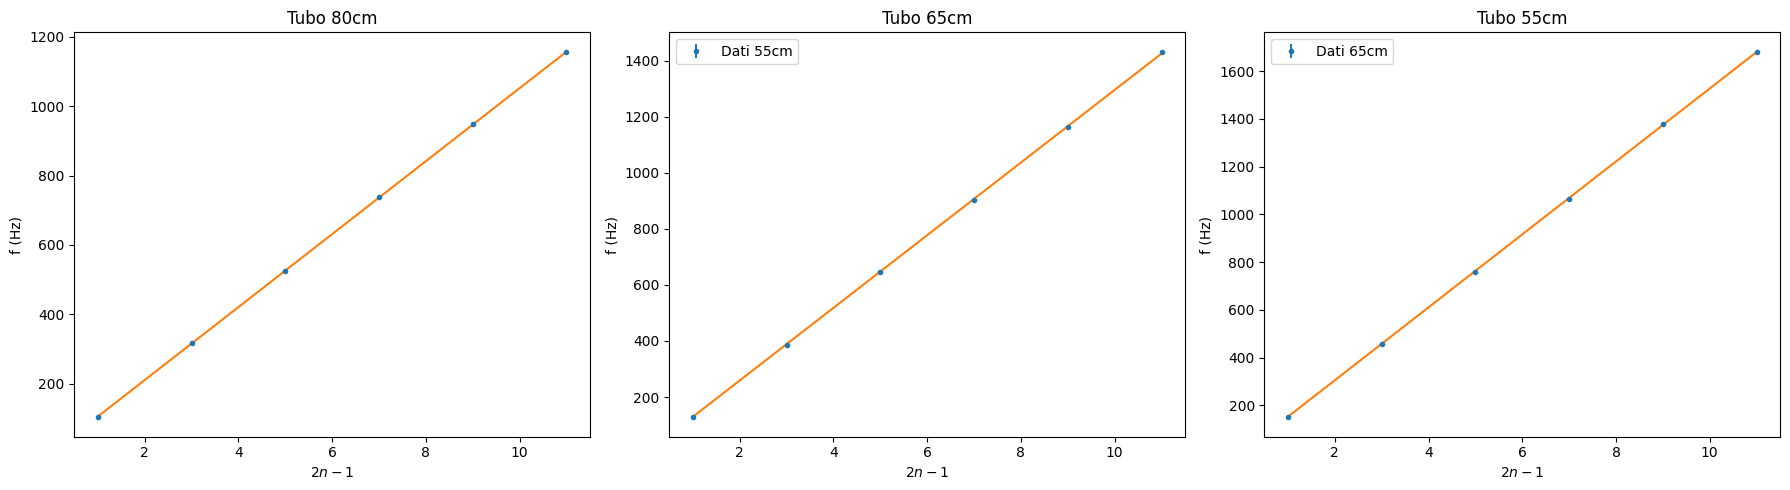

Il risultato del test del χ² è:
  χ²               = 0.40951049
  Gradi di libertà = 5
  χ² ridotto       = 0.081902098
  Il p-value associato è: 0.99506359
Il risultato del test del χ² è:
  χ²               = 1.891049
  Gradi di libertà = 5
  χ² ridotto       = 0.37820979
  Il p-value associato è: 0.86400578
Il risultato del test del χ² è:
  χ²               = 3.3377622
  Gradi di libertà = 5
  χ² ridotto       = 0.66755245
  Il p-value associato è: 0.64806545


In [101]:
 #--- FIT PASSANTE PER L'ORIGINE ---
n = pd.to_numeric(df9.iloc[1:7, 0], errors='coerce').dropna().values

f1 = pd.to_numeric(df9.iloc[1:7, 1], errors='coerce').dropna().values
sf1 = pd.to_numeric(df9.iloc[1:7, 2], errors='coerce').dropna().values

f2 = pd.to_numeric(df9.iloc[1:7, 3], errors='coerce').dropna().values
sf2 = pd.to_numeric(df9.iloc[1:7, 4], errors='coerce').dropna().values

f3 = pd.to_numeric(df9.iloc[1:7, 5], errors='coerce').dropna().values
sf3 = pd.to_numeric(df9.iloc[1:7, 6], errors='coerce').dropna().values

# Fit 80 cm
k1= ad.minquadw_kx(n, f1, sf1)

# Fit 65 cm
k2 = ad.minquadw_kx(n, f2, sf2)

# Fit 55 cm
k3= ad.minquadw_kx(n, f3, sf3)

def retta0(x, k):
    return k * x

t = np.linspace(min(n), max(n), 100)


import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- PLOT 1: 80cm ---
ax1.errorbar(n, f1, yerr=sf1, fmt='o', ls='none', label='Dati 80cm', ms=3)
ax1.plot(t, retta0(t, k1.nominal_value))
ax1.set_title('Tubo 80cm')
ax1.set_xlabel(r'$2n-1$')
ax1.set_ylabel(r'f (Hz)')

# --- PLOT 2: 55cm ---
ax2.errorbar(n, f2, yerr=sf2, fmt='o', ls='none', label='Dati 55cm', ms=3)
ax2.plot(t, retta0(t, k2.nominal_value))
ax2.set_title('Tubo 65cm')
ax2.set_xlabel(r'$2n-1$')
ax2.set_ylabel(r'f (Hz)')
ax2.legend()

# --- PLOT 3: 65cm ---
ax3.errorbar(n, f3, yerr=sf3, fmt='o', ls='none', label='Dati 65cm', ms=3)
ax3.plot(t, retta0(t, k3.nominal_value))
ax3.set_title('Tubo 55cm')
ax3.set_xlabel(r'$2n-1$')
ax3.set_ylabel(r'f (Hz)')
ax3.legend()

plt.tight_layout()
plt.show()

print("="*70)
ad.chi_quadro(f1, k1*n, sf1, 1)
print("="*70)
ad.chi_quadro(f2, k2*n, sf2, 1)
print("="*70)
ad.chi_quadro(f3, k3*n, sf3, 1)
print("="*70)

In [90]:
l1=0.80
l2=0.65
l3=0.55

v1_k=4*k1*(l1+0.4*D)
v2_k=4*k2*(l2+0.4*D)
v3_k=4*k3*(l3+0.4*D)

T1=ufloat(df9.iloc[0, 7], df9.iloc[2, 7])
v_suono_teorica=sqrt((γ*R*T1)/M)

print("="*70)
print(f"Velocità del suono (80cm)= {v1_k:.5P}")
print(f"Velocità del suono (65cm)= {v2_k:.5P}")
print(f"Velocità del suono (55cm)= {v3_k:.5P}")

print("="*70)
ad.t_test(v1_k, v, "v1_k", "v_exp")
ad.t_test(v2_k, v, "v2_k", "v_exp")
ad.t_test(v3_k, v, "v3_k", "v_exp")
print("="*70)
ad.t_test(v1_k, v_suono_teorica, "v1_k", "v_teo2")
ad.t_test(v2_k, v_suono_teorica, "v2_k", "v_teo2")
ad.t_test(v3_k, v_suono_teorica, "v3_k", "v_teo2")
print("="*70)


Velocità del suono (80cm)= 342.54±1.28
Velocità del suono (65cm)= 344.03±1.30
Velocità del suono (55cm)= 344.42±1.39
Test di compatibilità tra v1_k e v_exp: |t| = 1.6664912
Test di compatibilità tra v2_k e v_exp: |t| = 1.3280367
Test di compatibilità tra v3_k e v_exp: |t| = 1.2434229
Test di compatibilità tra v1_k e v_teo2: |t| = 0.48407255
Test di compatibilità tra v2_k e v_teo2: |t| = 0.026327558
Test di compatibilità tra v3_k e v_teo2: |t| = 0.093118376


# Argon e Kripton (Tubo Chiuso)

In [91]:
df7=pd.read_excel('Tubo risonanza.xlsx', sheet_name=3)
df7=df7.fillna('')
df7

,Argon,Unnamed: 1,Unnamed: 2,Unnamed: 3,Kripton,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,n,Frequenza (hz),Incertezza (hz),L (m),n,Frequenza (hz),Incertezza (hz),L (m)
1,1,112,5,1.46,1,94,5,1.454
2,2,225,5,T (K),2,188,5,T (K)
3,3,338,5,295.65,3,282,5,295.15
4,4,450,5,Incertezza temperatura (k),4,375,5,Incertezza temperatura (k)
5,5,562,5,0.5,5,469,5,0.5
6,6,676,5,Massa molare (kg/mol),6,560,5,Massa molare (kg/mol)
7,,,,0.039948,,,,0.083798
8,,,,Incertezza (kg/mol),,,,Incertezza (kg/mol)
9,,,,0.0005,,,,0.0005


Il risultato del fit y = k·x è:
  k = 112.54945±0.52414
Il risultato del fit y = k·x è:
  k = 93.637363±0.524142


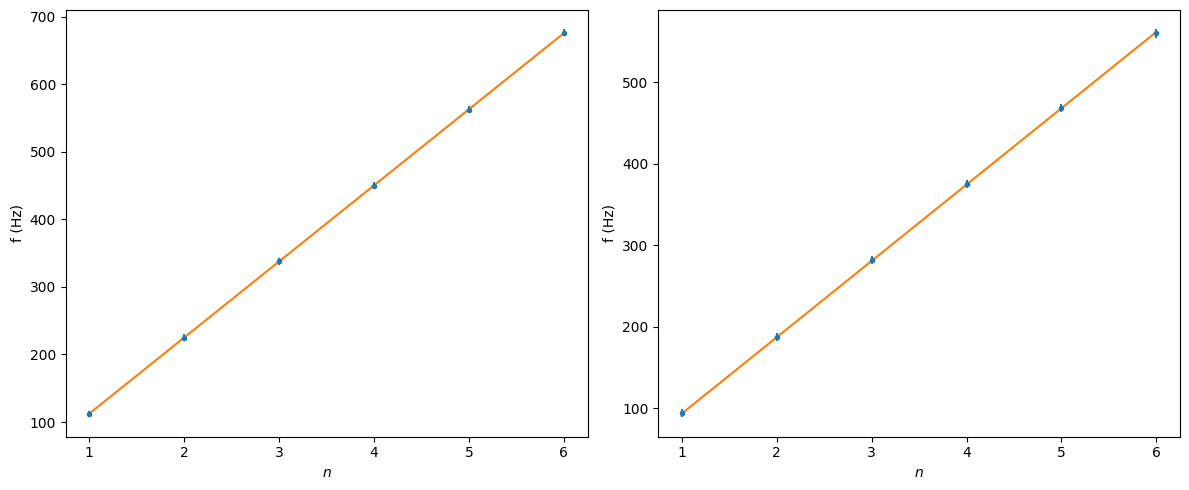

Il risultato del test del χ² è:
  χ²               = 0.061098901
  Gradi di libertà = 5
  χ² ridotto       = 0.01221978
  Il p-value associato è: 0.99995198
Il risultato del test del χ² è:
  χ²               = 0.24131868
  Gradi di libertà = 5
  χ² ridotto       = 0.048263736
  Il p-value associato è: 0.9986035


In [102]:
n2=pd.to_numeric(df7.iloc[1:7, 0], errors='coerce').dropna().values
fa=pd.to_numeric(df7.iloc[1:7, 1], errors='coerce').dropna().values
sfa=pd.to_numeric(df7.iloc[1:7, 2], errors='coerce').dropna().values
n3=pd.to_numeric(df7.iloc[1:7, 4], errors='coerce').dropna().values
fk=pd.to_numeric(df7.iloc[1:7, 5], errors='coerce').dropna().values
sfk=pd.to_numeric(df7.iloc[1:7, 6], errors='coerce').dropna().values

# --- FIT PASSANTE PER L'ORIGINE ---

# Argon
k4 = ad.minquadw_kx(n2, fa, sfa)

# Kripton
k5 = ad.minquadw_kx(n3, fk, sfk)

def retta0(x, k):
    return k * x

t = np.linspace(min(min(n2), min(n3)), max(max(n2), max(n3)), 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- PLOT 1: Argon ---
ax1.errorbar(n2, fa, yerr=sfa, fmt='o', ls='none', label='Argon', ms=3)
ax1.plot(t, retta0(t, k4.nominal_value), label='Fit')
ax1.set_xlabel(r'$n$')
ax1.set_ylabel(r'f (Hz)')

# --- PLOT 2: Kripton ---
ax2.errorbar(n3, fk, yerr=sfk, fmt='o', ls='none', label='Kripton', ms=3)
ax2.plot(t, retta0(t, k5.nominal_value), label='Fit')
ax2.set_xlabel(r'$n$')
ax2.set_ylabel(r'f (Hz)')

plt.tight_layout()
plt.show()

print("="*70)
ad.chi_quadro(fa, k4*n2, sfa, 1);
print("="*70)
ad.chi_quadro(fk, k5*n3, sfk, 1);
print("="*70)


In [99]:
L_tubo_argon=df7.iloc[1, 3]
L_tubo_kripton=df7.iloc[1, 7]
M_a=ufloat(df7.iloc[7, 3], df7.iloc[9, 3])
M_k=ufloat(df7.iloc[7, 7], df7.iloc[9, 3])
γ_m=df7.iloc[11, 3]
T_stanza_argon=ufloat(df7.iloc[3, 3], df7.iloc[5, 3])
T_stanza_kripton=ufloat(df7.iloc[3, 7], df7.iloc[5, 7])
v_suono1_teorica=sqrt((γ_m*R*T_stanza_argon)/M_a)
v_suono2_teorica=sqrt((γ_m*R*T_stanza_kripton)/M_k)
v_suono_argon=2*k4*(L_tubo_argon)
v_suono_kripton=2*k5*(L_tubo_kripton)

print("="*80)
print(f"Velocità del suono Argon teorica: {v_suono1_teorica:.5P}")
print(f"Velocità del suono Argon sperimentale: {v_suono_argon:.5P}")
ad.t_test(v_suono_argon, v_suono1_teorica, "v_argon_exp", "v_argon_teo")

print("="*80)

print(f"Velocità del suono Kripton sperimentale: {v_suono_kripton:.5P}")
print(f"Velocità del suono Kripton teorica: {v_suono2_teorica:.5P}")
ad.t_test(v_suono_kripton, v_suono2_teorica, "v_kripton_exp", "v_kripton_teo")
print("="*80)

Velocità del suono Argon teorica: 320.25±2.02
Velocità del suono Argon sperimentale: 328.64±1.53
Test di compatibilità tra v_argon_exp e v_argon_teo: |t| = 3.311646
Velocità del suono Kripton sperimentale: 272.30±1.52
Velocità del suono Kripton teorica: 220.93±0.69
Test di compatibilità tra v_kripton_exp e v_kripton_teo: |t| = 30.741001


# Onde quadre (aria)




In [94]:
df4=pd.read_excel('Tubo risonanza.xlsx', sheet_name=4)
df4=df4.fillna('')
df4

,x (m),sx (m),Delta T_1,Delta T_2,Δt medio (s)
0,1.57,0.005,0.00450,0.00450,0.004500
1,1.37,0.005,0.00392,0.00392,0.003920
2,1.17,0.005,0.00336,0.00335,0.003355
3,0.97,0.005,0.00279,0.00277,0.002780
4,0.77,0.005,0.00220,0.00220,0.002200
5,0.57,0.005,0.00162,0.00162,0.001620
6,0.37,0.005,0.00105,0.00104,0.001045


Il risultato del fit y = k·x è:
  k = 349.22535±0.63467


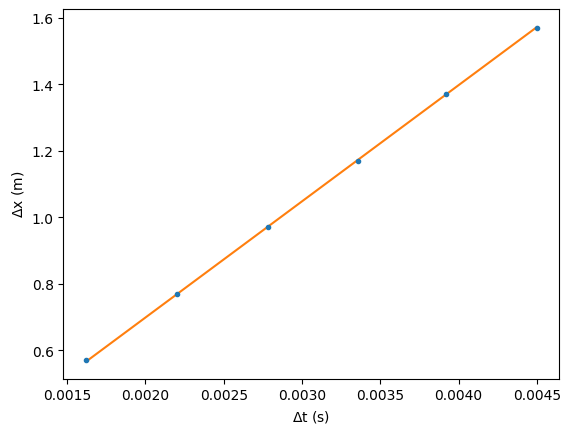

Il risultato del test del χ² è:
  χ²               = 1.1127342
  Gradi di libertà = 5
  χ² ridotto       = 0.22254684
  Il p-value associato è: 0.95297033
Velocità del suono (onda quadra)= 349.2±0.6
Test di compatibilità tra v_onda_quadra_exp e v_suono_teo: |t| = 1.385862
Test di compatibilità tra v_onda_quadra_exp e v_suono_exp: |t| = 0.048662962


In [103]:
x=pd.to_numeric(df4.iloc[0:6, 0], errors='coerce').dropna().values
t=pd.to_numeric(df4.iloc[0:6, 4], errors='coerce').dropna().values
sx=pd.to_numeric(df4.iloc[0:6, 1], errors='coerce').dropna().values
k6=ad.minquadw_kx(t, x, sx)
x_plot = np.linspace(min(t), max(t))

plt.errorbar(t, x, yerr=sx, fmt='o', ls='none', label='Dati', ms=3)

plt.plot(x_plot, x_plot * k6.nominal_value, label='Fit')
plt.xlabel(r'$\Delta$t (s)')
plt.ylabel(r'$\Delta$x (m)')
plt.show()

print("="*80)
ad.chi_quadro(x, k6 * t, np.full_like(x, sx), 1)
print("="*80)

print(f"Velocità del suono (onda quadra)= {k6:.4P}")
ad.t_test(k6, v_suono, "v_onda_quadra_exp", "v_suono_teo")
ad.t_test(k6, v, "v_onda_quadra_exp", "v_suono_exp")
print("="*80)

# Ampiezza e fase

In [95]:
df8=pd.read_excel('Tubo risonanza.xlsx', sheet_name=5)
df8.fillna('')


,Frequenza (hz),Ampiezza (V),Δt (s)
0,222,0.050,0.00064
1,232,0.070,0.00053
2,242,0.090,0.00040
3,252,0.164,0.00043
4,262,0.206,0.00055
5,272,0.270,0.00058
6,282,0.322,0.00069
7,292,0.278,0.00095
8,302,0.210,0.00144
9,312,0.166,0.00171


[0.0004  0.00043 0.00055 0.00058 0.00069 0.00095 0.00144 0.00171 0.00179
 0.0018  0.00181]


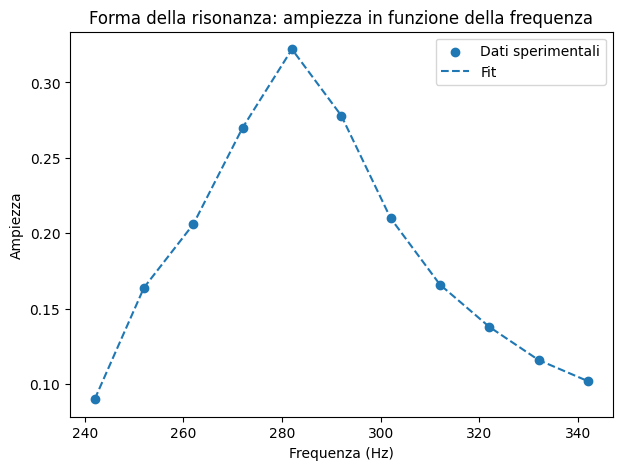

In [97]:
# Dati
f = pd.to_numeric(df8.iloc[2:13, 0], errors='coerce').dropna().values
A = pd.to_numeric(df8.iloc[2:13, 1], errors='coerce').dropna().values
t=pd.to_numeric(df8.iloc[2:13, 2], errors='coerce').dropna().values
print(t)
plt.figure(figsize=(7,5))
plt.scatter(f, A, label="Dati sperimentali")
plt.plot(f, A, label="Fit", linestyle='dashed')


plt.xlabel("Frequenza (Hz)")
plt.ylabel("Ampiezza")
plt.title("Forma della risonanza: ampiezza in funzione della frequenza")
plt.legend()
plt.show()


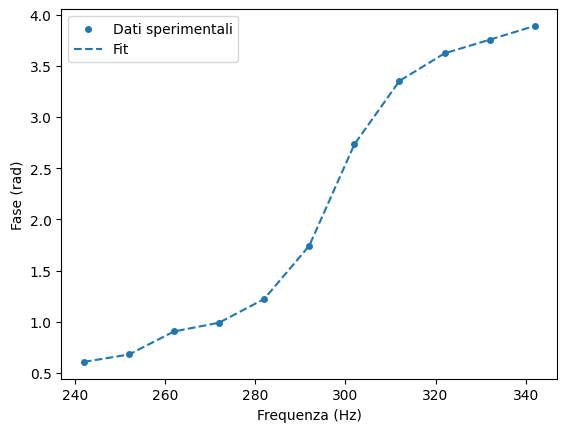

In [98]:
φ=2*np.pi*t*f
plt.scatter(f, φ, label="Dati sperimentali", s=16)
plt.plot(f, φ, label="Fit", linestyle='dashed')
plt.xlabel("Frequenza (Hz)")
plt.ylabel("Fase (rad)")
plt.legend()
plt.show()